LGBM & XGBM

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Reading the dataset
df=pd.read_csv("diabetes.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
# Check missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
# Checking for duplicates
df.duplicated().sum()

np.int64(0)

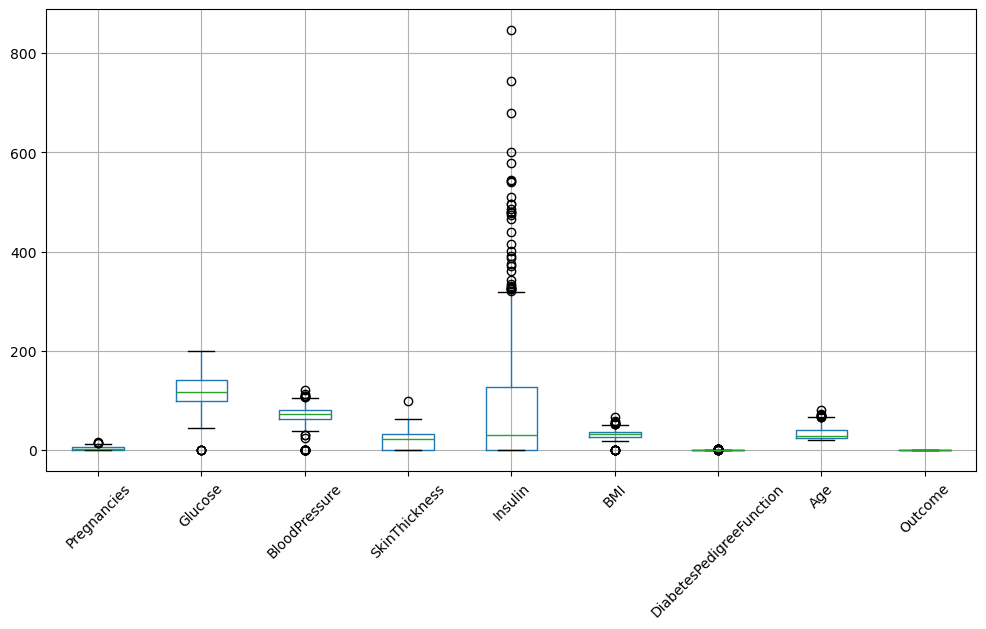

In [9]:
# checking for outliers
plt.figure(figsize=(12,6))
df.boxplot()
plt.xticks(rotation=45)
plt.show()

In [10]:
# Outlier treatment using IQR capping
def outlier_capping(df,columns):
    Q1= df[columns].quantile(0.25) # calculating Q1
    Q3= df[columns].quantile(0.75) # calculating Q3
    IQR= Q3-Q1 # calculating IQR
    lower_extreme= Q1-1.5*IQR # calculating Lower_extreme
    upper_extreme= Q3+1.5*IQR # calculating upper extreme
    df[columns]=df[columns].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
# replacing values less than lower_extreme with lower_extreme and values greater than upper_extreme with upper_extreme
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

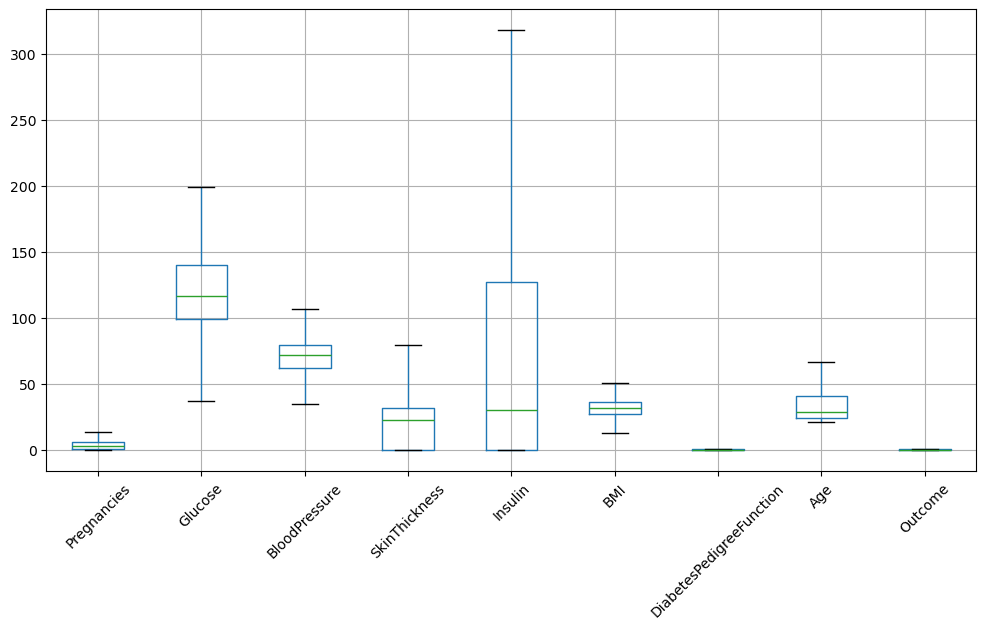

In [11]:
plt.figure(figsize=(12,6))
df.boxplot()
plt.xticks(rotation=45)
plt.show()# shows outliers are treated

In [12]:
df.describe() # statistical summary

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.837240,121.136230,70.684896,20.511719,73.652669,32.125065,0.458914,33.199870,0.348958
std,3.344157,31.187468,14.197239,15.844744,93.576029,7.049584,0.285596,11.628404,0.476951
min,0.000000,37.125000,35.000000,0.000000,0.000000,13.350000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,13.500000,199.000000,107.000000,80.000000,318.125000,50.550000,1.200000,66.500000,1.000000


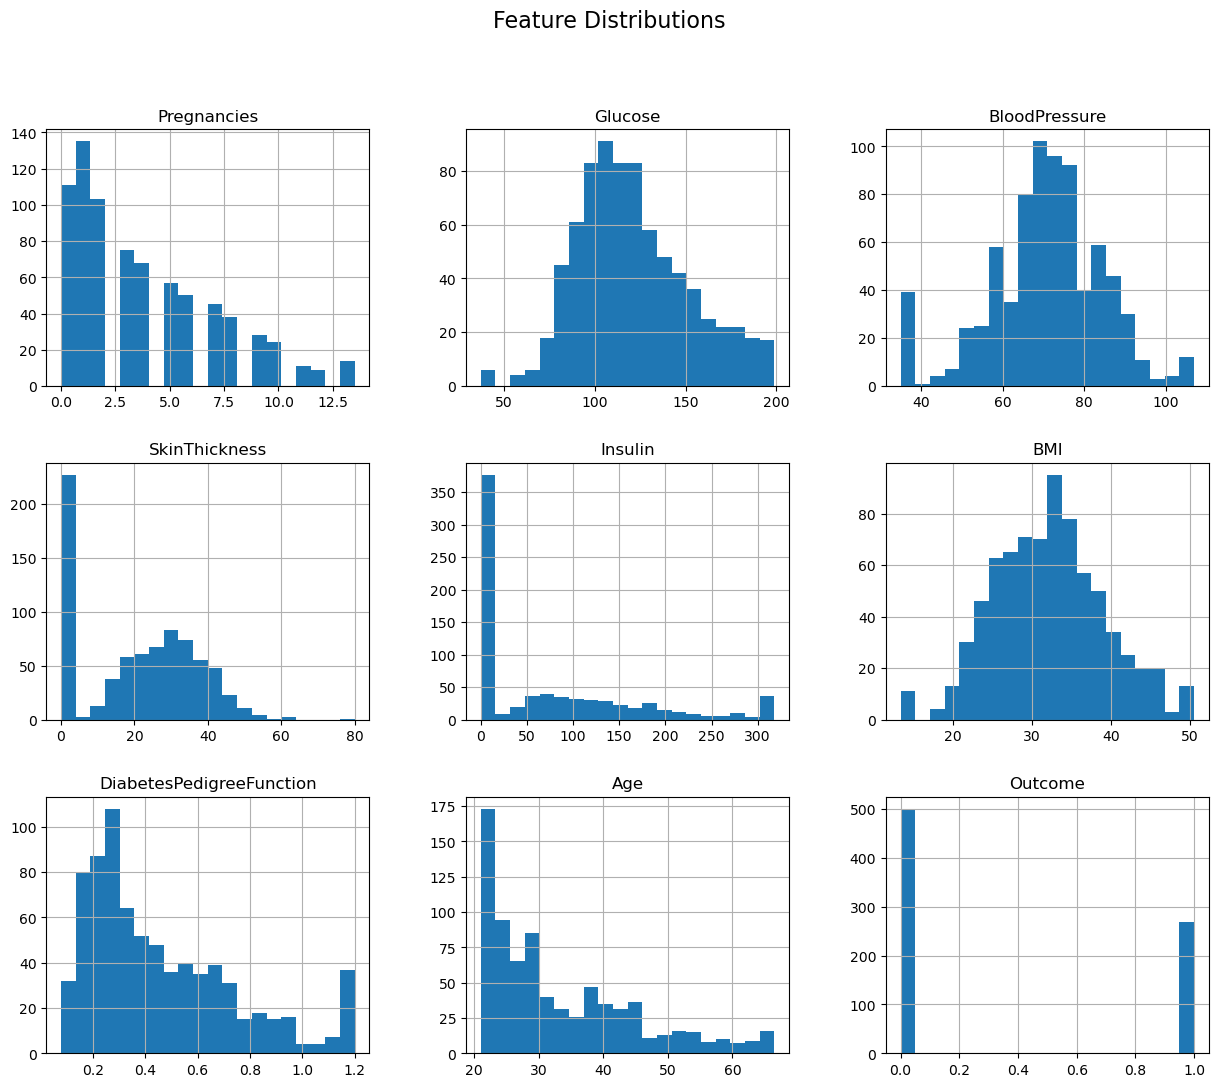

In [13]:
# Histogram
df.hist(figsize=(15,12), bins=20)
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

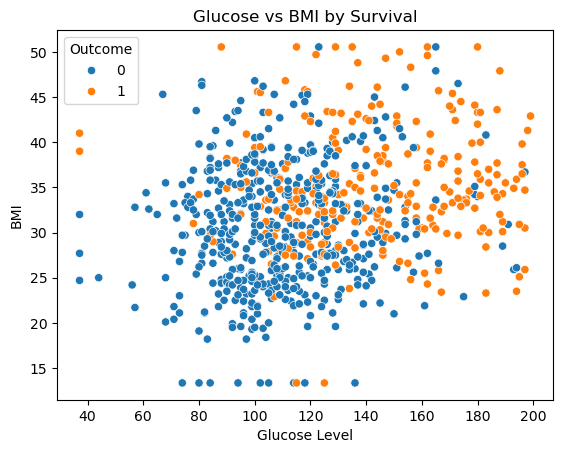

In [67]:
sns.scatterplot(x=df["Glucose"], y=df["BMI"],hue=df["Outcome"])
plt.xlabel("Glucose Level")
plt.ylabel("BMI")
plt.title("Glucose vs BMI by Survival")
plt.show()

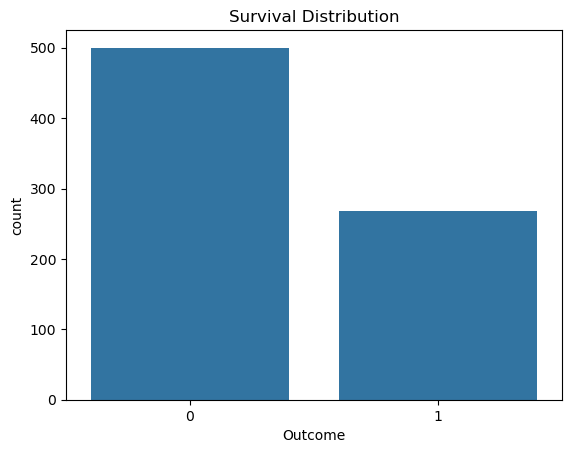

In [21]:
sns.countplot(x="Outcome", data=df)
plt.title("Survival Distribution")
plt.show()

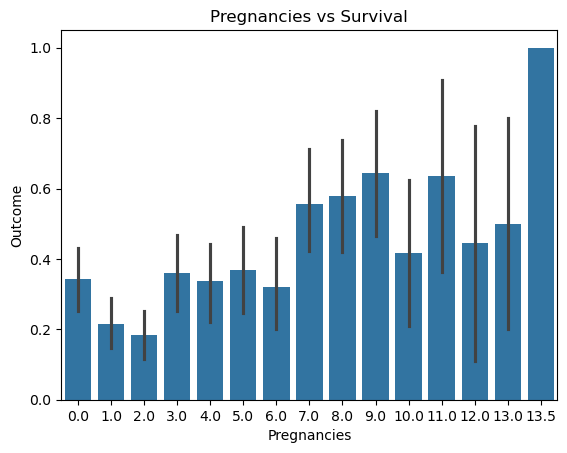

In [22]:
sns.barplot(x="Pregnancies", y="Outcome", data=df)
plt.title("Pregnancies vs Survival")
plt.show()

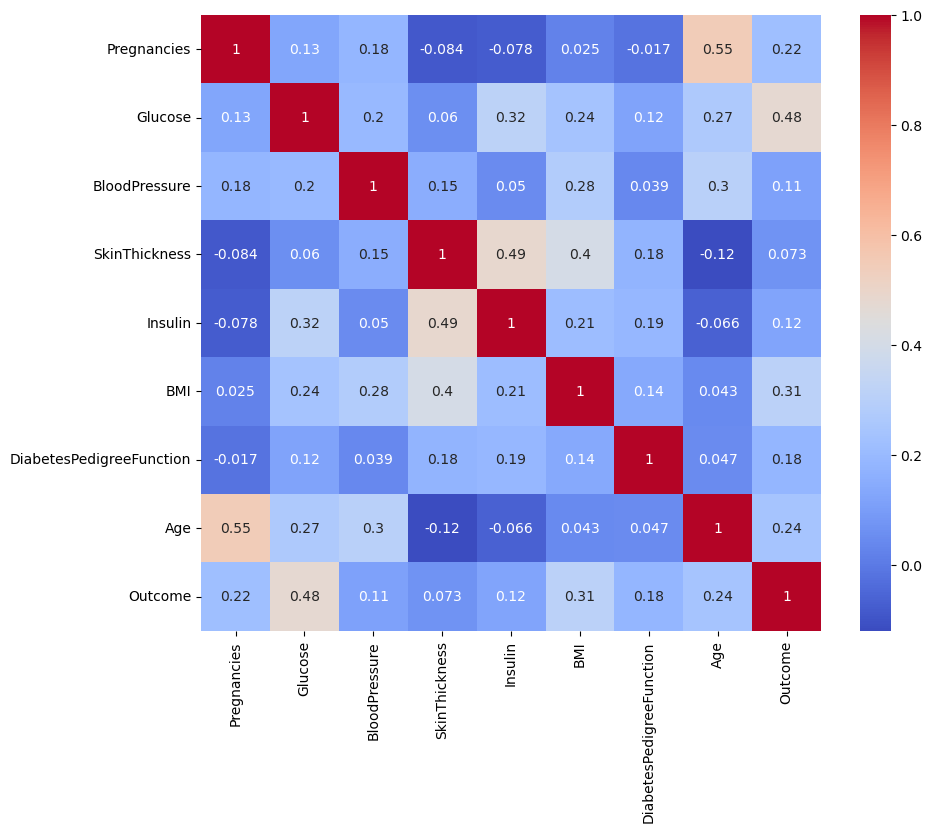

In [28]:
#Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [24]:
#Feature & Target Separation
features= df.drop(columns=['Outcome'])
target= df[['Outcome']]

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
# Splitting the dataset into train and test
x_train,x_test,y_train,y_test=train_test_split(features,target,train_size=0.8,random_state=150,stratify=target)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614, 1)
(154, 1)


In [30]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
std_sca=StandardScaler()

In [31]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10.0,101.0,76.0,48.0,180.0,32.9,0.171,63.0,0
764,2.0,122.0,70.0,27.0,0.0,36.8,0.340,27.0,0
765,5.0,121.0,72.0,23.0,112.0,26.2,0.245,30.0,0
766,1.0,126.0,60.0,0.0,0.0,30.1,0.349,47.0,1
767,1.0,93.0,70.0,31.0,0.0,30.4,0.315,23.0,0


In [33]:
# Scaling  features
x_train[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','Age']]= std_sca.fit_transform(x_train[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','Age']])
# Scaling x test features
x_test[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','Age']]= std_sca.transform(x_test[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','Age']])


In [35]:
x_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
340,-0.834004,0.289438,-0.008786,-0.455837,0.333220,-0.882094,0.472,-0.956916
241,0.062544,-0.938706,-0.008786,0.737564,0.153787,0.146448,0.446,-0.956916
652,0.361394,0.069002,0.275142,1.240049,0.037683,0.289301,0.269,-0.437232
86,2.752189,-0.466343,0.133178,2.119397,-0.775042,0.646433,0.178,1.035208
632,-0.535155,-0.308889,-0.718607,-1.272375,-0.775042,-0.839239,0.343,-0.870302
...,...,...,...,...,...,...,...,...
131,1.556791,0.037511,-1.002536,-1.272375,-0.775042,0.175018,1.114,-0.004161
18,-0.834004,-0.560816,-2.493160,1.114428,0.101013,1.603549,0.183,-0.004161
480,-0.236305,1.171182,-0.008786,0.611943,2.582727,0.489295,0.344,0.169067
399,-0.236305,2.273362,-0.008786,0.674753,-0.775042,0.403583,0.241,-0.697074


In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [39]:
!pip install xgboost
import xgboost as xgb

In [40]:
xg_boost= xgb.XGBClassifier(n_estimators=100,learning_rate=0.1,min_child_weight=1,
    subsample=0.9,max_features=1,reg_alpha=10,reg_lambda=10)
xg_boost.fit(x_train,y_train)
y_pred= xg_boost.predict(x_test)
xgb_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred)
}
xgb_results

{'Accuracy': 0.7272727272727273,
 'Precision': 0.6304347826086957,
 'Recall': 0.5370370370370371,
 'F1-score': 0.58}

In [64]:
#Hyperparameter tuning 
xg_boost= xgb.XGBClassifier(n_estimators=50,learning_rate=0.5,min_child_weight=1,
    subsample=0.9,max_features=2,reg_alpha=5,reg_lambda=5)
xg_boost.fit(x_train,y_train)
y_pred= xg_boost.predict(x_test)
xgb_results1 = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred)
}
xgb_results1

{'Accuracy': 0.7532467532467533,
 'Precision': 0.6538461538461539,
 'Recall': 0.6296296296296297,
 'F1-score': 0.6415094339622641}

In [56]:
# Gridsearch for getting the best parameters
from sklearn.model_selection import GridSearchCV
params={'n_estimators':[50,100],'learning_rate':[0.1,0.5],'min_child_weight':[1,2,3]}

In [57]:
grid_search= GridSearchCV(estimator=xg_boost,param_grid=params, cv=5)
grid_search.fit(x_train,y_train)
grid_search.best_params_, grid_search.best_score_

({'learning_rate': 0.5, 'min_child_weight': 1, 'n_estimators': 100},
 np.float64(0.7768492602958815))

In [44]:
!pip install lightgbm
import lightgbm as lgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 24.9 MB/s eta 0:00:00


In [45]:
lgb= lgbm.LGBMClassifier(n_estimators=100,learning_rate=0.1,min_child_weight=1,
                            subsample=0.9,max_features=1,reg_alpha=10,reg_lambda=10,
                             max_bins=10,bundled=True,boosting_type='goss',top_rate=0.2,other_rate=0.3)

In [46]:
lgb.fit(x_train,y_train)
y_pred= lgb.predict(x_test)
lgbm_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred)
}
lgbm_results

[LightGBM] [Warning] Unknown parameter: max_features
[LightGBM] [Warning] Unknown parameter: bundled
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Unknown parameter: max_features
[LightGBM] [Warning] Unknown parameter: bundled
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000087 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 80
[LightGBM] [Info] Number of data points in the 

{'Accuracy': 0.7077922077922078,
 'Precision': 0.5849056603773585,
 'Recall': 0.5740740740740741,
 'F1-score': 0.5794392523364486}

In [65]:
#Hyperparameter tuning
lgb= lgbm.LGBMClassifier(n_estimators=50,learning_rate=0.5,min_child_weight=2,
                            subsample=0.9,max_features=3,reg_alpha=5,reg_lambda=5,
                             max_bins=10,bundled=True,boosting_type='goss',top_rate=0.2,other_rate=0.3)

In [66]:
lgb.fit(x_train,y_train)
y_pred= lgb.predict(x_test)
lgbm_results1 = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred)
}
lgbm_results1

[LightGBM] [Warning] Unknown parameter: max_features
[LightGBM] [Warning] Unknown parameter: bundled
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Unknown parameter: max_features
[LightGBM] [Warning] Unknown parameter: bundled
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000346 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 80
[LightGBM] [Info] Number of data points in the 

{'Accuracy': 0.7272727272727273,
 'Precision': 0.5967741935483871,
 'Recall': 0.6851851851851852,
 'F1-score': 0.6379310344827587}

In [58]:
comparison = pd.DataFrame([lgbm_results, xgb_results],
                           index=["LightGBM", "XGBoost"])
comparison

,Accuracy,Precision,Recall,F1-score
LightGBM,0.707792,0.584906,0.574074,0.579439
XGBoost,0.727273,0.630435,0.537037,0.580000
